<a href="https://colab.research.google.com/github/iammarkdelacruz/aimcapstone_identify_patterns_associated_wASD/blob/main/ASD_Child_Screening_Capstone_Revised_Leakage_Controlled.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explainable Machine Learning for Autism Spectrum Disorder Screening in Children

## Revised Capstone Notebook — Leakage-Controlled Analysis

This revised notebook addresses the main methodological issues identified in the first run:

1. **Retains all 292 observations** because identical feature profiles are not automatically assumed to be duplicate respondents.
2. Uses an explicit **`Unknown` category** for missing categorical values rather than imputing the most frequent category.
3. Runs three modelling scenarios:
   - **Scenario A — Full / Leakage-Prone Model**
   - **Scenario B — Behavioural Screening Model without `result`**
   - **Scenario C — Context-Only Model without `result` and A1–A10**
4. Compares Logistic Regression, Decision Tree, Random Forest, XGBoost, and SVM using the same validation framework.
5. Selects the best **leakage-controlled** model for final interpretation.
6. Runs SHAP / model-based explainability and fairness auditing only on the selected leakage-controlled model.

> This notebook models **ASD screening classification**, not clinical diagnosis, and does not establish causation.

## 1. Install packages

In [1]:
!pip -q install ucimlrepo xgboost shap fairlearn joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 13.2 MB/s eta 0:00:00


## 2. Imports and reproducibility

In [2]:
import os
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.inspection import PartialDependenceDisplay
import shap
import joblib

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

for folder in [
    "models",
    "results",
    "results/figures",
    "results/tables",
    "configs"
]:
    os.makedirs(folder, exist_ok=True)

print("Setup complete.")

Setup complete.


# STEP 2/3 — Dataset Loading, Understanding, and Preprocessing

## 3. Load UCI dataset

In [3]:
asd = fetch_ucirepo(id=419)

X_raw = asd.data.features.copy()
y_raw = asd.data.targets.copy()

print("Feature shape:", X_raw.shape)
print("Target shape:", y_raw.shape)

display(X_raw.head())
display(y_raw.head())

Feature shape: (292, 20)
Target shape: (292, 1)


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,autism,country_of_res,used_app_before,result,age_desc,relation
0,1,1,0,0,1,1,0,1,0,0,6.0,m,Others,no,no,Jordan,no,5,'4-11 years',Parent
1,1,1,0,0,1,1,0,1,0,0,6.0,m,'Middle Eastern ',no,no,Jordan,no,5,'4-11 years',Parent
2,1,1,0,0,0,1,1,1,0,0,6.0,m,NaN,no,no,Jordan,yes,5,'4-11 years',NaN
3,0,1,0,0,1,1,0,0,0,1,5.0,f,NaN,yes,no,Jordan,no,4,'4-11 years',NaN
4,1,1,1,1,1,1,1,1,1,1,5.0,m,Others,yes,no,'United States',no,10,'4-11 years',Parent


,class
0,NO
1,NO
2,NO
3,NO
4,YES


In [4]:
print("Metadata")
print(asd.metadata)

print("\nVariables")
display(asd.variables)

Metadata
{'uci_id': 419, 'name': 'Autistic Spectrum Disorder Screening Data for Children  ', 'repository_url': 'https://archive.ics.uci.edu/dataset/419/autistic+spectrum+disorder+screening+data+for+children', 'data_url': 'https://archive.ics.uci.edu/static/public/419/data.csv', 'abstract': 'Children screening data for autism suitable for classification and predictive tasks ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 292, 'num_features': 20, 'feature_types': ['Integer'], 'demographics': ['\x00', 'Age', 'Gender', 'Ethnicity', 'Nationality'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2017, 'last_updated': 'Wed Apr 03 2024', 'dataset_doi': '10.24432/C5659W', 'creators': ['Fadi Thabtah'], 'intro_paper': None, 'additional_info': {'summary': "see attached file for variables' description ", 'purpose': None, 'funded_by': None, 'insta

,name,role,type,demographic,description,units,missing_values
0,A1_Score,Feature,Integer,None,None,None,no
1,A2_Score,Feature,Integer, ,None,None,no
2,A3_Score,Feature,Integer,None,None,None,no
3,A4_Score,Feature,Integer,None,None,None,no
4,A5_Score,Feature,Integer,None,None,None,no
5,A6_Score,Feature,Integer,None,None,None,no
6,A7_Score,Feature,Integer,None,None,None,no
7,A8_Score,Feature,Integer,None,None,None,no
8,A9_Score,Feature,Integer,None,None,None,no
9,A10_Score,Feature,Integer,None,None,None,no


## 4. Build working DataFrame

In [5]:
target_name = y_raw.columns[0]
df = pd.concat([X_raw, y_raw], axis=1)

print("Original dataset shape:", df.shape)
print("Target column:", target_name)

display(df.head())

Original dataset shape: (292, 21)
Target column: class


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jaundice,autism,country_of_res,used_app_before,result,age_desc,relation,class
0,1,1,0,0,1,1,0,1,0,0,...,m,Others,no,no,Jordan,no,5,'4-11 years',Parent,NO
1,1,1,0,0,1,1,0,1,0,0,...,m,'Middle Eastern ',no,no,Jordan,no,5,'4-11 years',Parent,NO
2,1,1,0,0,0,1,1,1,0,0,...,m,NaN,no,no,Jordan,yes,5,'4-11 years',NaN,NO
3,0,1,0,0,1,1,0,0,0,1,...,f,NaN,yes,no,Jordan,no,4,'4-11 years',NaN,NO
4,1,1,1,1,1,1,1,1,1,1,...,m,Others,yes,no,'United States',no,10,'4-11 years',Parent,YES


## 5. Standardize missing values

The UCI data may include nulls and historical missing-value symbols. These are standardized to `NaN`.

In [6]:
df = df.replace("?", np.nan)

missing_table = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percent": (df.isna().mean() * 100).round(2)
})

missing_table = missing_table[
    missing_table["Missing_Count"] > 0
].sort_values("Missing_Count", ascending=False)

display(missing_table)

missing_table.to_csv(
    "results/tables/missing_values.csv"
)

,Missing_Count,Missing_Percent
ethnicity,43,14.73
relation,43,14.73
age,4,1.37


## 6. Duplicate-profile inspection

Identical rows are **not automatically removed**. Without a participant identifier, identical feature profiles may represent different children. All observations are retained unless the source metadata proves duplicated respondents.

In [7]:
duplicate_count = df.duplicated().sum()

print("Identical feature/target profiles found:", duplicate_count)

if duplicate_count > 0:
    display(df[df.duplicated(keep=False)].head(20))

print("Rows retained for analysis:", len(df))

Identical feature/target profiles found: 2


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jaundice,autism,country_of_res,used_app_before,result,age_desc,relation,class
51,0,0,1,0,1,1,1,0,1,1,...,m,Asian,no,no,India,no,6,'4-11 years',Parent,NO
84,0,0,1,0,1,1,1,0,1,1,...,m,Asian,no,no,India,no,6,'4-11 years',Parent,NO
92,0,0,1,1,1,1,1,1,1,1,...,m,Asian,no,no,India,no,8,'4-11 years',Parent,YES
93,0,0,1,1,1,1,1,1,1,1,...,m,Asian,no,no,India,no,8,'4-11 years',Parent,YES


Rows retained for analysis: 292


## 7. Standardize target

In [8]:
print("Original target values:")
print(df[target_name].value_counts(dropna=False))

target_map = {
    "YES": 1, "Yes": 1, "yes": 1,
    "NO": 0,  "No": 0,  "no": 0
}

df["target"] = df[target_name].map(target_map)

if df["target"].isna().sum() > 0:
    raise ValueError(
        "Target conversion failed for some values. "
        "Inspect df[target_name].value_counts(dropna=False)."
    )

df["target"] = df["target"].astype(int)
print(df["target"].value_counts())

Original target values:
class
NO     151
YES    141
Name: count, dtype: int64
target
0    151
1    141
Name: count, dtype: int64


## 8. Target distribution

,Count,Percent
target,,
0,151,51.71
1,141,48.29


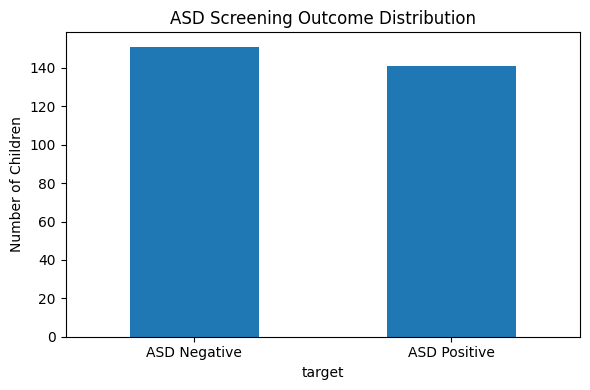

In [9]:
target_counts = df["target"].value_counts().sort_index()

target_distribution = pd.DataFrame({
    "Count": target_counts,
    "Percent": (
        target_counts / target_counts.sum() * 100
    ).round(2)
})

display(target_distribution)

target_distribution.to_csv(
    "results/tables/target_distribution.csv"
)

plt.figure(figsize=(6,4))
target_counts.plot(kind="bar")
plt.xticks([0,1], ["ASD Negative", "ASD Positive"], rotation=0)
plt.ylabel("Number of Children")
plt.title("ASD Screening Outcome Distribution")
plt.tight_layout()
plt.savefig("results/figures/target_distribution.png", bbox_inches="tight")
plt.show()

## 9. Initial data audit

In [10]:
audit_table = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "unique_values": df.nunique(dropna=False),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
})

display(audit_table)
audit_table.to_csv("results/tables/data_audit.csv")

,dtype,unique_values,missing,missing_pct
A1_Score,int64,2,0,0.00
A2_Score,int64,2,0,0.00
A3_Score,int64,2,0,0.00
A4_Score,int64,2,0,0.00
A5_Score,int64,2,0,0.00
A6_Score,int64,2,0,0.00
A7_Score,int64,2,0,0.00
A8_Score,int64,2,0,0.00
A9_Score,int64,2,0,0.00
A10_Score,int64,2,0,0.00


## 10. Separate predictors

In [11]:
X_all = df.drop(
    columns=[target_name, "target"],
    errors="ignore"
).copy()

y = df["target"].copy()

numeric_cols = X_all.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_all.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'result']
Categorical columns: ['gender', 'ethnicity', 'jaundice', 'autism', 'country_of_res', 'used_app_before', 'age_desc', 'relation']


## 11. EDA — Behavioural screening items

In [12]:
behavior_cols = [
    col for col in X_all.columns
    if col.lower().startswith("a")
    and "_score" in col.lower()
]

print("Behavioural features:", behavior_cols)

Behavioural features: ['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score']


,ASD_Negative,ASD_Positive
A1_Score,0.450331,0.829787
A2_Score,0.423841,0.652482
A3_Score,0.576159,0.921986
A4_Score,0.278146,0.843972
A5_Score,0.582781,0.914894
A6_Score,0.529801,0.907801
A7_Score,0.476821,0.744681
A8_Score,0.284768,0.723404
A9_Score,0.258278,0.744681
A10_Score,0.536424,0.929078


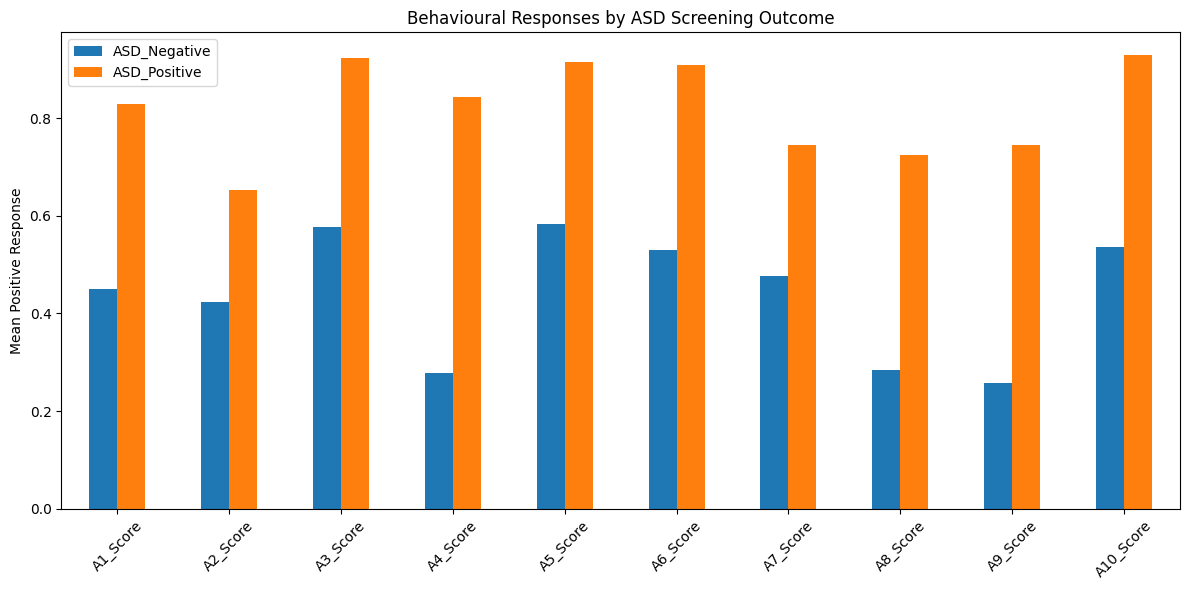

In [13]:
if behavior_cols:
    behavior_target = df[behavior_cols + ["target"]].copy()

    for col in behavior_cols:
        behavior_target[col] = pd.to_numeric(
            behavior_target[col],
            errors="coerce"
        )

    behavior_by_target = (
        behavior_target
        .groupby("target")[behavior_cols]
        .mean()
        .T
    )

    behavior_by_target.columns = [
        "ASD_Negative",
        "ASD_Positive"
    ]

    display(behavior_by_target)

    behavior_by_target.to_csv(
        "results/tables/behavior_by_target.csv"
    )

    behavior_by_target.plot(kind="bar", figsize=(12,6))
    plt.ylabel("Mean Positive Response")
    plt.title("Behavioural Responses by ASD Screening Outcome")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(
        "results/figures/behavior_by_target.png",
        bbox_inches="tight"
    )
    plt.show()

## 12. Outlier analysis

In [14]:
outlier_summary = []

for col in numeric_cols:
    s = pd.to_numeric(X_all[col], errors="coerce").dropna()

    if s.nunique() <= 2:
        continue

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    n_outliers = ((s < lower) | (s > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Q1": q1,
        "Q3": q3,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Potential_Outliers": n_outliers
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

outlier_df.to_csv(
    "results/tables/outlier_summary.csv",
    index=False
)

,Feature,Q1,Q3,Lower_Bound,Upper_Bound,Potential_Outliers
0,age,4.0,8.0,-2.0,14.0,0
1,result,5.0,8.0,0.5,12.5,1


## 13. Correlation matrix

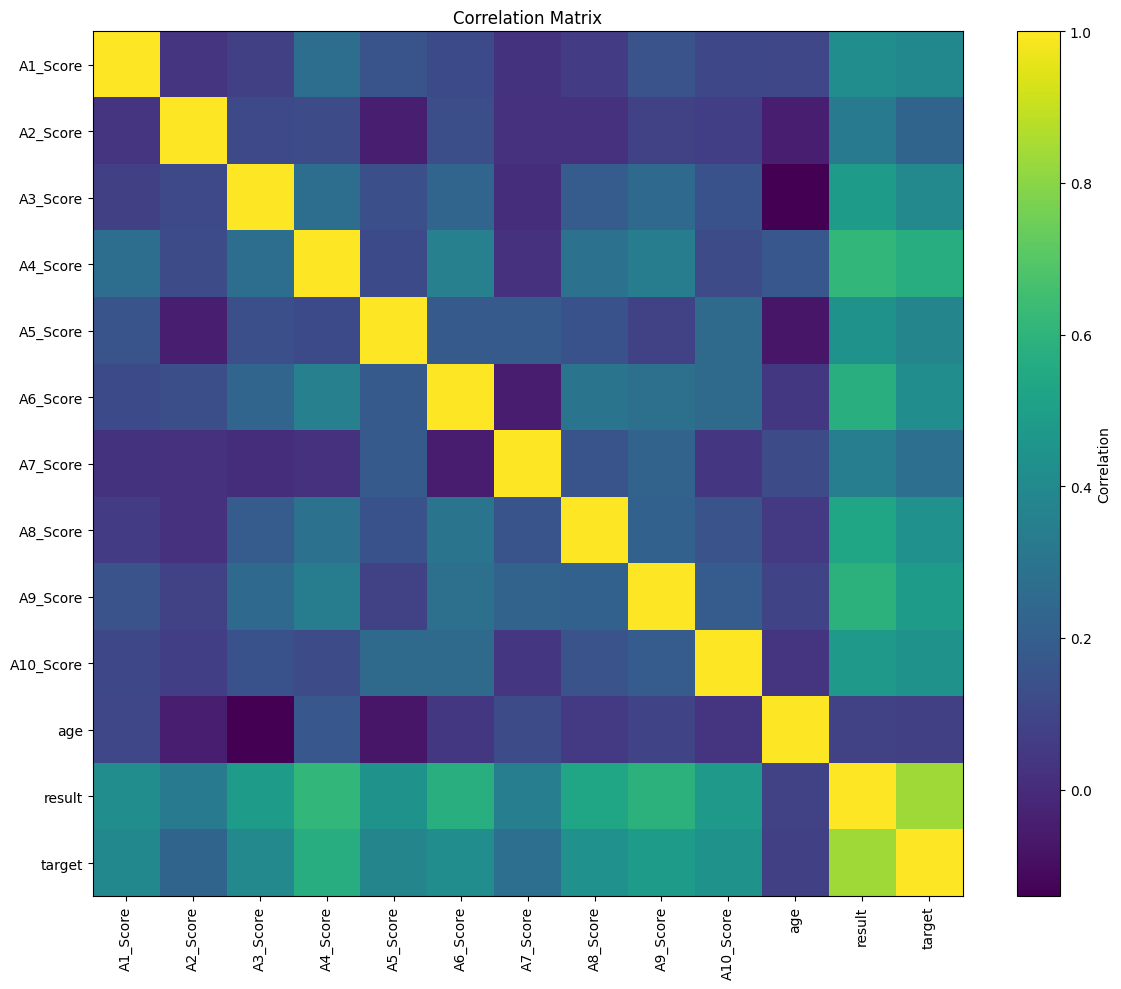

In [15]:
numeric_for_corr = df[
    list(dict.fromkeys(numeric_cols + ["target"]))
].apply(pd.to_numeric, errors="coerce")

corr = numeric_for_corr.corr()

plt.figure(figsize=(12,10))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar(label="Correlation")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("results/figures/correlation_matrix.png", bbox_inches="tight")
plt.show()

# STEP 3 — Feature Engineering, Feature Selection, and Dimensionality Reduction

## 14. Engineered behavioural count for EDA only

This is not used blindly in modelling because it may reproduce the screening score.

In [16]:
if behavior_cols:
    df["behavior_positive_count"] = (
        df[behavior_cols]
        .apply(pd.to_numeric, errors="coerce")
        .sum(axis=1)
    )

    display(df[["behavior_positive_count", "target"]].head())

,behavior_positive_count,target
0,5,0
1,5,0
2,5,0
3,4,0
4,10,1


## 15. Define the three modelling scenarios

### Scenario A — Full / Leakage-Prone
All original predictors, including `result`.

### Scenario B — Behavioural Screening Model
Removes `result` but keeps A1–A10 and contextual features.

### Scenario C — Context-Only Model
Removes `result` and A1–A10, leaving demographic/family/context variables only.

In [17]:
RESULT_COL = "result" if "result" in X_all.columns else None

scenario_A_features = X_all.columns.tolist()

scenario_B_features = [
    col for col in X_all.columns
    if col != RESULT_COL
]

scenario_C_features = [
    col for col in X_all.columns
    if col != RESULT_COL and col not in behavior_cols
]

SCENARIOS = {
    "A_Full_Leakage_Prone": scenario_A_features,
    "B_No_Result": scenario_B_features,
    "C_Context_Only": scenario_C_features
}

for name, features in SCENARIOS.items():
    print(name, "=>", len(features), "features")
    print(features)
    print()

A_Full_Leakage_Prone => 20 features
['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender', 'ethnicity', 'jaundice', 'autism', 'country_of_res', 'used_app_before', 'result', 'age_desc', 'relation']

B_No_Result => 19 features
['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender', 'ethnicity', 'jaundice', 'autism', 'country_of_res', 'used_app_before', 'age_desc', 'relation']

C_Context_Only => 9 features
['age', 'gender', 'ethnicity', 'jaundice', 'autism', 'country_of_res', 'used_app_before', 'age_desc', 'relation']



## 16. Shared preprocessing function

Categorical missing values are encoded as `Unknown` rather than replaced by the majority class.

In [18]:
def build_preprocessor(X):

    numeric_features = (
        X.select_dtypes(include=np.number)
        .columns
        .tolist()
    )

    categorical_features = (
        X.select_dtypes(exclude=np.number)
        .columns
        .tolist()
    )

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="constant",
                    fill_value="Unknown"
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            )
        ]
    )

    transformers = []

    if numeric_features:
        transformers.append(
            ("num", numeric_transformer, numeric_features)
        )

    if categorical_features:
        transformers.append(
            ("cat", categorical_transformer, categorical_features)
        )

    preprocessor = ColumnTransformer(
        transformers=transformers
    )

    return preprocessor, numeric_features, categorical_features

## 17. Shared stratified train/test split

In [19]:
all_indices = np.arange(len(df))

train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("Train rows:", len(train_idx))
print("Test rows:", len(test_idx))
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Train rows: 233
Test rows: 59

Train target distribution:
target
0    0.515021
1    0.484979
Name: proportion, dtype: float64

Test target distribution:
target
0    0.525424
1    0.474576
Name: proportion, dtype: float64


## 18. Feature selection and PCA on Scenario B

In [20]:
X_B = X_all[SCENARIOS["B_No_Result"]].copy()

X_B_train = X_B.iloc[train_idx].copy()
X_B_test = X_B.iloc[test_idx].copy()

preprocessor_B, numeric_B, categorical_B = build_preprocessor(X_B_train)

X_B_train_processed = preprocessor_B.fit_transform(X_B_train)
X_B_test_processed = preprocessor_B.transform(X_B_test)

feature_names_B = preprocessor_B.get_feature_names_out()

print("Processed Scenario B shape:", X_B_train_processed.shape)

Processed Scenario B shape: (233, 80)


### 18.1 Mutual Information

In [21]:
mi = mutual_info_classif(
    X_B_train_processed,
    y_train,
    random_state=SEED
)

mi_df = pd.DataFrame({
    "Feature": feature_names_B,
    "Mutual_Information": mi
}).sort_values("Mutual_Information", ascending=False)

display(mi_df.head(20))

mi_df.to_csv(
    "results/tables/scenario_B_mutual_information.csv",
    index=False
)

,Feature,Mutual_Information
3,num__A4_Score,0.175160
8,num__A9_Score,0.144642
2,num__A3_Score,0.112456
9,num__A10_Score,0.111520
4,num__A5_Score,0.100039
7,num__A8_Score,0.090375
0,num__A1_Score,0.086461
1,num__A2_Score,0.064937
19,cat__ethnicity_Others,0.062729
29,cat__country_of_res_'Isle of Man',0.055170


### 18.2 Recursive Feature Elimination

In [22]:
n_select = min(10, X_B_train_processed.shape[1])

rfe_model = LogisticRegression(
    max_iter=5000,
    random_state=SEED
)

rfe = RFE(
    estimator=rfe_model,
    n_features_to_select=n_select
)

rfe.fit(X_B_train_processed, y_train)

rfe_df = pd.DataFrame({
    "Feature": feature_names_B,
    "Selected": rfe.support_,
    "Rank": rfe.ranking_
}).sort_values("Rank")

display(rfe_df.head(20))

rfe_df.to_csv(
    "results/tables/scenario_B_rfe.csv",
    index=False
)

,Feature,Selected,Rank
0,num__A1_Score,True,1
1,num__A2_Score,True,1
2,num__A3_Score,True,1
3,num__A4_Score,True,1
4,num__A5_Score,True,1
5,num__A6_Score,True,1
6,num__A7_Score,True,1
7,num__A8_Score,True,1
8,num__A9_Score,True,1
9,num__A10_Score,True,1


### 18.3 PCA

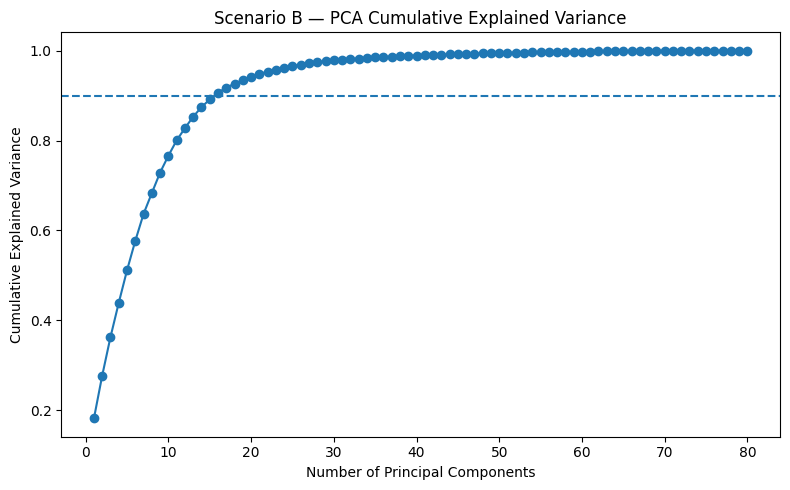

In [23]:
pca_full = PCA()
pca_full.fit(X_B_train_processed)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)
plt.axhline(y=0.90, linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scenario B — PCA Cumulative Explained Variance")
plt.tight_layout()
plt.savefig(
    "results/figures/scenario_B_pca_variance.png",
    bbox_inches="tight"
)
plt.show()

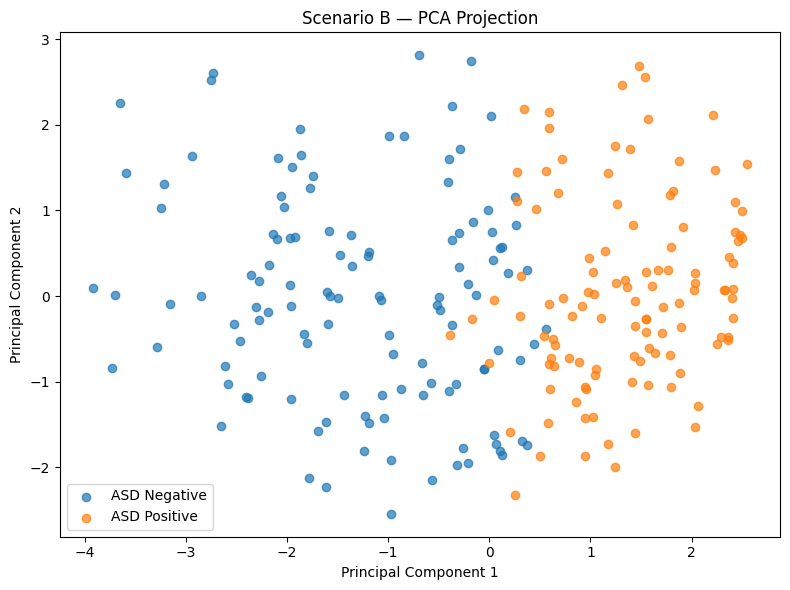

Variance explained by first 2 PCs: 0.2769206553884238


In [24]:
pca2 = PCA(n_components=2, random_state=SEED)
X_pca = pca2.fit_transform(X_B_train_processed)

plt.figure(figsize=(8,6))

for cls, label in [
    (0, "ASD Negative"),
    (1, "ASD Positive")
]:
    mask = y_train.to_numpy() == cls
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=label,
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Scenario B — PCA Projection")
plt.legend()
plt.tight_layout()
plt.savefig(
    "results/figures/scenario_B_pca_2d.png",
    bbox_inches="tight"
)
plt.show()

print(
    "Variance explained by first 2 PCs:",
    pca2.explained_variance_ratio_.sum()
)

# STEP 4 — Multi-Scenario Model Implementation and Comparison

## 19. Candidate models

In [25]:
def get_models():
    return {
        "Dummy": DummyClassifier(
            strategy="most_frequent"
        ),

        "Logistic Regression": LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=SEED
        ),

        "Decision Tree": DecisionTreeClassifier(
            class_weight="balanced",
            random_state=SEED
        ),

        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=SEED
        ),

        "XGBoost": XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=SEED,
            eval_metric="logloss"
        ),

        "SVM": SVC(
            probability=True,
            class_weight="balanced",
            random_state=SEED
        )
    }

## 20. Cross-validation across all scenarios

In [26]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

all_cv_results = []

for scenario_name, feature_list in SCENARIOS.items():

    X_scenario = X_all[feature_list].copy()
    X_train_s = X_scenario.iloc[train_idx].copy()

    preprocessor_s, _, _ = build_preprocessor(X_train_s)

    for model_name, model in get_models().items():

        pipe = Pipeline(
            steps=[
                ("preprocessor", preprocessor_s),
                ("model", model)
            ]
        )

        scores = cross_validate(
            pipe,
            X_train_s,
            y_train,
            cv=cv,
            scoring=scoring,
            error_score=np.nan
        )

        all_cv_results.append({
            "Scenario": scenario_name,
            "Model": model_name,
            "CV Accuracy": np.nanmean(scores["test_accuracy"]),
            "CV Precision": np.nanmean(scores["test_precision"]),
            "CV Recall": np.nanmean(scores["test_recall"]),
            "CV F1": np.nanmean(scores["test_f1"]),
            "CV ROC-AUC": np.nanmean(scores["test_roc_auc"]),
            "ROC-AUC SD": np.nanstd(scores["test_roc_auc"]),
            "CV PR-AUC": np.nanmean(scores["test_pr_auc"])
        })

scenario_cv_df = pd.DataFrame(all_cv_results)

display(
    scenario_cv_df.sort_values(
        ["Scenario", "CV ROC-AUC"],
        ascending=[True, False]
    )
)

scenario_cv_df.to_csv(
    "results/tables/all_scenarios_cv_results.csv",
    index=False
)

,Scenario,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,ROC-AUC SD,CV PR-AUC
1,A_Full_Leakage_Prone,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
2,A_Full_Leakage_Prone,Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
3,A_Full_Leakage_Prone,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
4,A_Full_Leakage_Prone,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
5,A_Full_Leakage_Prone,SVM,0.970028,0.974275,0.965217,0.968674,0.998913,0.002174,0.998926
0,A_Full_Leakage_Prone,Dummy,0.515079,0.000000,0.000000,0.000000,0.500000,0.000000,0.484921
7,B_No_Result,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
11,B_No_Result,SVM,0.957169,0.956851,0.956522,0.955740,0.996706,0.002409,0.996707
10,B_No_Result,XGBoost,0.957169,0.944250,0.973518,0.957118,0.988258,0.006686,0.988358
9,B_No_Result,Random Forest,0.918501,0.937036,0.894466,0.913884,0.981028,0.004648,0.982255


## 21. Scenario-level ROC-AUC comparison

In [27]:
pivot_auc = scenario_cv_df.pivot(
    index="Model",
    columns="Scenario",
    values="CV ROC-AUC"
)

display(pivot_auc)

pivot_auc.to_csv(
    "results/tables/scenario_model_auc_comparison.csv"
)

Scenario,A_Full_Leakage_Prone,B_No_Result,C_Context_Only
Model,,,
Decision Tree,1.000000,0.857872,0.544656
Dummy,0.500000,0.500000,0.500000
Logistic Regression,1.000000,1.000000,0.589196
Random Forest,1.000000,0.981028,0.593017
SVM,0.998913,0.996706,0.593775
XGBoost,1.000000,0.988258,0.613027


## 22. Tune Logistic Regression and Random Forest within each scenario

All five substantive model families are compared above. Logistic Regression and Random Forest are then tuned as strong interpretable/nonlinear representatives.

In [28]:
scenario_tuning_results = []
scenario_best_estimators = {}

for scenario_name, feature_list in SCENARIOS.items():

    X_scenario = X_all[feature_list].copy()

    X_train_s = X_scenario.iloc[train_idx].copy()

    preprocessor_s, _, _ = build_preprocessor(X_train_s)

    log_pipe = Pipeline([
        ("preprocessor", preprocessor_s),
        (
            "model",
            LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                random_state=SEED
            )
        )
    ])

    log_search = GridSearchCV(
        log_pipe,
        {
            "model__C": [0.01, 0.1, 1, 10, 100]
        },
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    log_search.fit(X_train_s, y_train)

    rf_pipe = Pipeline([
        ("preprocessor", preprocessor_s),
        (
            "model",
            RandomForestClassifier(
                class_weight="balanced",
                random_state=SEED
            )
        )
    ])

    rf_search = GridSearchCV(
        rf_pipe,
        {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 3, 5, 8],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2"]
        },
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    rf_search.fit(X_train_s, y_train)

    candidates = {
        "Logistic Regression": log_search,
        "Random Forest": rf_search
    }

    best_name = max(
        candidates,
        key=lambda k: candidates[k].best_score_
    )

    best_search = candidates[best_name]
    best_estimator = best_search.best_estimator_

    scenario_best_estimators[scenario_name] = {
        "name": best_name,
        "estimator": best_estimator,
        "params": best_search.best_params_,
        "cv_auc": best_search.best_score_
    }

    scenario_tuning_results.append({
        "Scenario": scenario_name,
        "Selected Tuned Model": best_name,
        "Best CV ROC-AUC": best_search.best_score_,
        "Best Parameters": str(best_search.best_params_)
    })

scenario_tuning_df = pd.DataFrame(
    scenario_tuning_results
)

display(scenario_tuning_df)

scenario_tuning_df.to_csv(
    "results/tables/scenario_tuning_results.csv",
    index=False
)

,Scenario,Selected Tuned Model,Best CV ROC-AUC,Best Parameters
0,A_Full_Leakage_Prone,Logistic Regression,1.000000,{'model__C': 0.01}
1,B_No_Result,Logistic Regression,1.000000,{'model__C': 0.1}
2,C_Context_Only,Random Forest,0.619368,"{'model__max_depth': 5, 'model__max_features':..."


## 23. Evaluate each scenario's tuned model on the same test set

In [29]:
scenario_test_results = []

for scenario_name, feature_list in SCENARIOS.items():

    X_scenario = X_all[feature_list].copy()

    X_train_s = X_scenario.iloc[train_idx].copy()
    X_test_s = X_scenario.iloc[test_idx].copy()

    selected = scenario_best_estimators[
        scenario_name
    ]

    estimator = selected["estimator"]

    estimator.fit(X_train_s, y_train)

    y_pred = estimator.predict(X_test_s)

    if hasattr(estimator, "predict_proba"):
        y_prob = estimator.predict_proba(X_test_s)[:, 1]
    else:
        y_prob = estimator.decision_function(X_test_s)

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=[0,1]
    )

    tn, fp, fn, tp = cm.ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    fnr = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else np.nan
    )

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else np.nan
    )

    scenario_test_results.append({
        "Scenario": scenario_name,
        "Model": selected["name"],
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "Specificity": specificity,
        "F1": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test, y_prob
        ),
        "PR-AUC": average_precision_score(
            y_test, y_prob
        ),
        "FNR": fnr,
        "FPR": fpr
    })

scenario_test_df = pd.DataFrame(
    scenario_test_results
)

display(scenario_test_df)

scenario_test_df.to_csv(
    "results/tables/scenario_test_results.csv",
    index=False
)

,Scenario,Model,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,PR-AUC,FNR,FPR
0,A_Full_Leakage_Prone,Logistic Regression,0.983051,0.965517,1.000000,0.967742,0.982456,1.000000,1.000000,0.000000,0.032258
1,B_No_Result,Logistic Regression,0.983051,0.965517,1.000000,0.967742,0.982456,1.000000,1.000000,0.000000,0.032258
2,C_Context_Only,Random Forest,0.525424,0.500000,0.535714,0.516129,0.517241,0.604263,0.593587,0.464286,0.483871


## 24. Select the final leakage-controlled model

Scenario A is intentionally excluded from final model selection.

In [30]:
leakage_controlled_names = [
    "B_No_Result",
    "C_Context_Only"
]

eligible = scenario_test_df[
    scenario_test_df["Scenario"].isin(
        leakage_controlled_names
    )
].copy()

eligible = eligible.sort_values(
    by=["ROC-AUC", "Recall", "F1"],
    ascending=False
)

display(eligible)

FINAL_SCENARIO = eligible.iloc[0]["Scenario"]

final_info = scenario_best_estimators[
    FINAL_SCENARIO
]

FINAL_MODEL_NAME = final_info["name"]
final_model = final_info["estimator"]

print("Final leakage-controlled scenario:", FINAL_SCENARIO)
print("Selected model:", FINAL_MODEL_NAME)
print("CV ROC-AUC:", final_info["cv_auc"])
print("Parameters:", final_info["params"])

,Scenario,Model,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,PR-AUC,FNR,FPR
1,B_No_Result,Logistic Regression,0.983051,0.965517,1.000000,0.967742,0.982456,1.000000,1.000000,0.000000,0.032258
2,C_Context_Only,Random Forest,0.525424,0.500000,0.535714,0.516129,0.517241,0.604263,0.593587,0.464286,0.483871


Final leakage-controlled scenario: B_No_Result
Selected model: Logistic Regression
CV ROC-AUC: 1.0
Parameters: {'model__C': 0.1}


## 25. Save final model and configuration

In [31]:
final_feature_list = SCENARIOS[
    FINAL_SCENARIO
]

X_final = X_all[
    final_feature_list
].copy()

X_final_train = X_final.iloc[
    train_idx
].copy()

X_final_test = X_final.iloc[
    test_idx
].copy()

final_model.fit(
    X_final_train,
    y_train
)

joblib.dump(
    final_model,
    "models/final_leakage_controlled_model.joblib"
)

config = {
    "random_seed": SEED,
    "test_size": 0.20,
    "cv_folds": 5,
    "target": target_name,
    "final_scenario": FINAL_SCENARIO,
    "final_model": FINAL_MODEL_NAME,
    "features": final_feature_list,
    "parameters": final_info["params"],
    "cv_roc_auc": float(final_info["cv_auc"])
}

with open(
    "configs/final_model_config.json",
    "w"
) as f:
    json.dump(config, f, indent=4)

print("Saved final model and config.")

Saved final model and config.


# STEP 5 — Critical Thinking, Explainability, and Bias Auditing

## 26. Final predictions

In [32]:
final_y_pred = final_model.predict(
    X_final_test
)

if hasattr(final_model, "predict_proba"):
    final_y_prob = final_model.predict_proba(
        X_final_test
    )[:,1]
else:
    final_y_prob = final_model.decision_function(
        X_final_test
    )

## 27. Generalization / overfitting check

In [33]:
if hasattr(final_model, "predict_proba"):
    train_prob = final_model.predict_proba(
        X_final_train
    )[:,1]
else:
    train_prob = final_model.decision_function(
        X_final_train
    )

train_auc = roc_auc_score(
    y_train,
    train_prob
)

test_auc = roc_auc_score(
    y_test,
    final_y_prob
)

generalization_gap = train_auc - test_auc

print("Training ROC-AUC:", train_auc)
print("Testing ROC-AUC:", test_auc)
print("Generalization gap:", generalization_gap)

Training ROC-AUC: 1.0
Testing ROC-AUC: 1.0
Generalization gap: 0.0


## 28. Confusion matrix

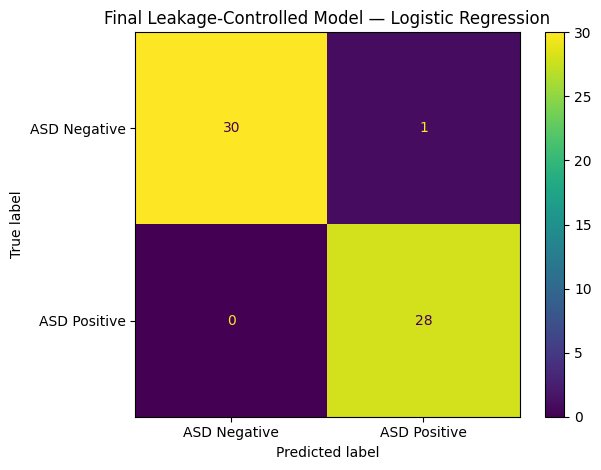

In [34]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_y_pred,
    display_labels=[
        "ASD Negative",
        "ASD Positive"
    ]
)

plt.title(
    f"Final Leakage-Controlled Model — {FINAL_MODEL_NAME}"
)
plt.tight_layout()
plt.savefig(
    "results/figures/final_confusion_matrix.png",
    bbox_inches="tight"
)
plt.show()

## 29. ROC and Precision-Recall curves

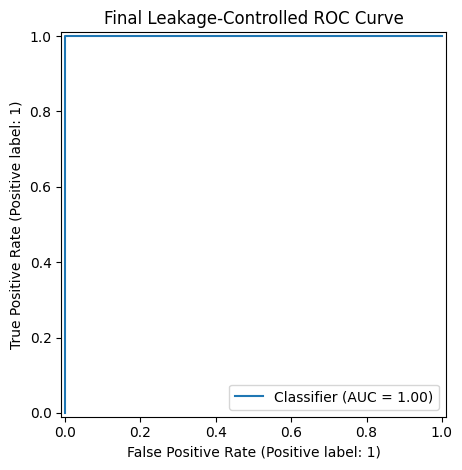

In [35]:
RocCurveDisplay.from_predictions(
    y_test,
    final_y_prob
)

plt.title("Final Leakage-Controlled ROC Curve")
plt.tight_layout()
plt.savefig(
    "results/figures/final_roc_curve.png",
    bbox_inches="tight"
)
plt.show()

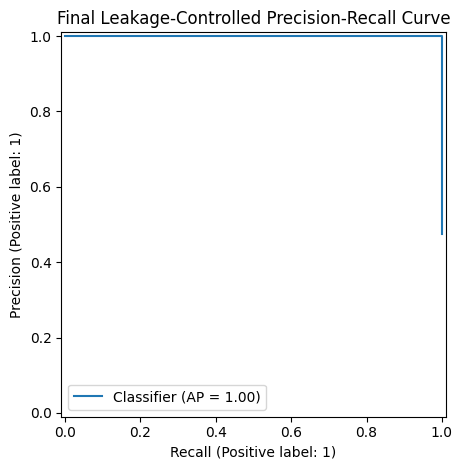

In [36]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    final_y_prob
)

plt.title(
    "Final Leakage-Controlled Precision-Recall Curve"
)
plt.tight_layout()
plt.savefig(
    "results/figures/final_pr_curve.png",
    bbox_inches="tight"
)
plt.show()

## 30. Explainability setup

In [37]:
final_preprocessor = final_model.named_steps[
    "preprocessor"
]

final_classifier = final_model.named_steps[
    "model"
]

X_final_train_transformed = (
    final_preprocessor.transform(
        X_final_train
    )
)

X_final_test_transformed = (
    final_preprocessor.transform(
        X_final_test
    )
)

final_feature_names = (
    final_preprocessor
    .get_feature_names_out()
)

print(
    "Transformed feature count:",
    len(final_feature_names)
)

Transformed feature count: 80


## 31. Model-based feature importance / coefficients

In [38]:
if hasattr(final_classifier, "feature_importances_"):

    importance_df = pd.DataFrame({
        "Feature": final_feature_names,
        "Importance": final_classifier.feature_importances_
    }).sort_values("Importance", ascending=False)

    display(importance_df.head(20))

    importance_df.to_csv(
        "results/tables/final_feature_importance.csv",
        index=False
    )

    top_features = importance_df.head(15)

    plt.figure(figsize=(10,6))
    plt.barh(
        top_features["Feature"][::-1],
        top_features["Importance"][::-1]
    )
    plt.xlabel("Feature Importance")
    plt.title("Final Model Feature Importance")
    plt.tight_layout()
    plt.savefig(
        "results/figures/final_feature_importance.png",
        bbox_inches="tight"
    )
    plt.show()

elif hasattr(final_classifier, "coef_"):

    coef_df = pd.DataFrame({
        "Feature": final_feature_names,
        "Coefficient": final_classifier.coef_[0]
    })

    coef_df["Absolute_Coefficient"] = (
        coef_df["Coefficient"].abs()
    )

    coef_df = coef_df.sort_values(
        "Absolute_Coefficient",
        ascending=False
    )

    display(coef_df.head(20))

    coef_df.to_csv(
        "results/tables/final_logistic_coefficients.csv",
        index=False
    )

,Feature,Coefficient,Absolute_Coefficient
3,num__A4_Score,0.828995,0.828995
9,num__A10_Score,0.824325,0.824325
0,num__A1_Score,0.648720,0.648720
4,num__A5_Score,0.624119,0.624119
7,num__A8_Score,0.593143,0.593143
6,num__A7_Score,0.558293,0.558293
2,num__A3_Score,0.547557,0.547557
8,num__A9_Score,0.534974,0.534974
1,num__A2_Score,0.498806,0.498806
5,num__A6_Score,0.421495,0.421495


## 32. SHAP

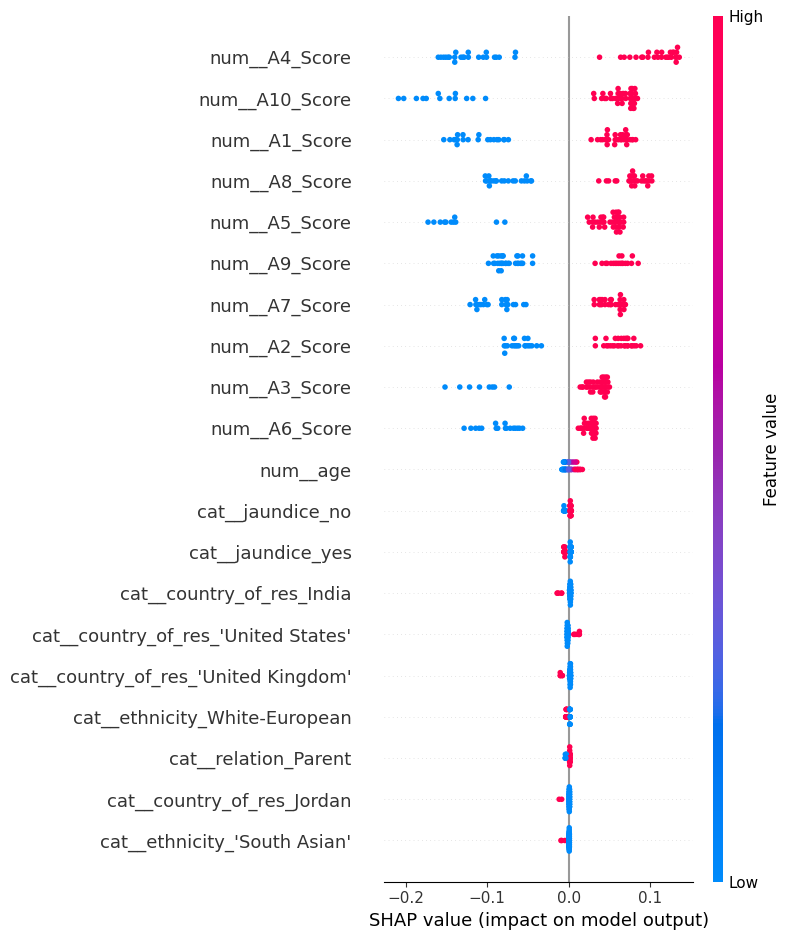

In [39]:
try:
    if hasattr(final_classifier, "feature_importances_"):

        explainer = shap.TreeExplainer(
            final_classifier
        )

        shap_values = explainer(
            X_final_test_transformed
        )

        print(
            "SHAP output shape:",
            shap_values.values.shape
        )

        if len(shap_values.values.shape) == 3:
            values_to_plot = shap_values.values[:, :, 1]
        else:
            values_to_plot = shap_values.values

        shap.summary_plot(
            values_to_plot,
            X_final_test_transformed,
            feature_names=final_feature_names,
            show=False
        )

        plt.tight_layout()
        plt.savefig(
            "results/figures/final_shap_summary.png",
            bbox_inches="tight"
        )
        plt.show()

    else:
        background = X_final_train_transformed[
            :min(100, len(X_final_train_transformed))
        ]

        explainer = shap.Explainer(
            final_classifier.predict_proba,
            background
        )

        sample = X_final_test_transformed[
            :min(50, len(X_final_test_transformed))
        ]

        shap_values = explainer(sample)

        if len(shap_values.values.shape) == 3:
            values_to_plot = shap_values.values[:, :, 1]
        else:
            values_to_plot = shap_values.values

        shap.summary_plot(
            values_to_plot,
            sample,
            feature_names=final_feature_names,
            show=False
        )

        plt.tight_layout()
        plt.savefig(
            "results/figures/final_shap_summary.png",
            bbox_inches="tight"
        )
        plt.show()

except Exception as e:
    print("SHAP generation failed.")
    print("Reason:", e)

## 33. Partial Dependence

In [40]:
final_numeric_cols = (
    X_final_train
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

if final_numeric_cols:
    try:
        PartialDependenceDisplay.from_estimator(
            final_model,
            X_final_train,
            features=[final_numeric_cols[0]]
        )

        plt.tight_layout()
        plt.savefig(
            "results/figures/final_pdp.png",
            bbox_inches="tight"
        )
        plt.show()

    except Exception as e:
        print("PDP could not be generated:", e)
else:
    print("No numeric feature available for PDP.")

PDP could not be generated: cannot reshape array of size 1 into shape (2)


## 34. Fairness audit helper

In [41]:
def subgroup_metrics(data):

    results = []

    for group, subset in data.groupby("group"):

        n = len(subset)

        if n < 5:
            results.append({
                "Group": group,
                "N": n,
                "Recall": np.nan,
                "Specificity": np.nan,
                "FPR": np.nan,
                "FNR": np.nan,
                "Selection_Rate": np.nan,
                "Note":
                    "Too few observations for stable interpretation"
            })
            continue

        y_true = subset["actual"]
        y_hat = subset["prediction"]

        cm = confusion_matrix(
            y_true,
            y_hat,
            labels=[0,1]
        )

        tn, fp, fn, tp = cm.ravel()

        recall = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else np.nan
        )

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else np.nan
        )

        fpr = (
            fp / (fp + tn)
            if (fp + tn) > 0
            else np.nan
        )

        fnr = (
            fn / (fn + tp)
            if (fn + tp) > 0
            else np.nan
        )

        selection_rate = y_hat.mean()

        results.append({
            "Group": group,
            "N": n,
            "Recall": recall,
            "Specificity": specificity,
            "FPR": fpr,
            "FNR": fnr,
            "Selection_Rate": selection_rate,
            "Note": ""
        })

    return pd.DataFrame(results)

## 35. Gender / sex fairness audit

In [42]:
sensitive_candidates = [
    col for col in X_final_test.columns
    if "gender" in col.lower()
    or col.lower() == "sex"
]

print(
    "Sensitive candidates:",
    sensitive_candidates
)

if sensitive_candidates:

    sensitive_col = sensitive_candidates[0]

    gender_audit_data = pd.DataFrame({
        "actual": y_test.values,
        "prediction": final_y_pred,
        "probability": final_y_prob,
        "group": X_final_test[sensitive_col].values
    })

    gender_audit = subgroup_metrics(
        gender_audit_data
    )

    display(gender_audit)

    gender_audit.to_csv(
        "results/tables/final_gender_fairness.csv",
        index=False
    )

Sensitive candidates: ['gender']


,Group,N,Recall,Specificity,FPR,FNR,Selection_Rate,Note
0,f,16,1.0,1.000000,0.000000,0.0,0.437500,
1,m,43,1.0,0.954545,0.045455,0.0,0.511628,


## 36. Fairness summary metrics

In [43]:
if sensitive_candidates:

    valid = gender_audit.dropna(
        subset=[
            "Recall",
            "FPR",
            "Selection_Rate"
        ]
    )

    if len(valid) >= 2:

        demographic_parity_difference = (
            valid["Selection_Rate"].max()
            -
            valid["Selection_Rate"].min()
        )

        disparate_impact_ratio = (
            valid["Selection_Rate"].min()
            /
            valid["Selection_Rate"].max()
            if valid["Selection_Rate"].max() > 0
            else np.nan
        )

        equal_opportunity_difference = (
            valid["Recall"].max()
            -
            valid["Recall"].min()
        )

        tpr_gap = (
            valid["Recall"].max()
            -
            valid["Recall"].min()
        )

        fpr_gap = (
            valid["FPR"].max()
            -
            valid["FPR"].min()
        )

        fairness_summary = pd.DataFrame({
            "Metric": [
                "Demographic Parity Difference",
                "Disparate Impact Ratio",
                "Equal Opportunity Difference",
                "TPR Gap",
                "FPR Gap"
            ],
            "Value": [
                demographic_parity_difference,
                disparate_impact_ratio,
                equal_opportunity_difference,
                tpr_gap,
                fpr_gap
            ]
        })

        display(fairness_summary)

        fairness_summary.to_csv(
            "results/tables/final_fairness_summary.csv",
            index=False
        )

    else:
        print(
            "Not enough stable subgroup results "
            "for fairness summary."
        )

,Metric,Value
0,Demographic Parity Difference,0.074128
1,Disparate Impact Ratio,0.855114
2,Equal Opportunity Difference,0.000000
3,TPR Gap,0.000000
4,FPR Gap,0.045455


## 37. Age fairness audit

In [44]:
age_candidates = [
    c for c in X_final_test.columns
    if c.lower() == "age"
]

if age_candidates:

    age_col = age_candidates[0]

    age_numeric = pd.to_numeric(
        X_final_test[age_col],
        errors="coerce"
    )

    age_group = pd.cut(
        age_numeric,
        bins=[
            -np.inf,
            5,
            8,
            12,
            np.inf
        ],
        labels=[
            "<=5",
            "6-8",
            "9-12",
            "13+"
        ]
    )

    age_audit_data = pd.DataFrame({
        "actual": y_test.values,
        "prediction": final_y_pred,
        "probability": final_y_prob,
        "group": age_group.values
    }).dropna()

    age_audit = subgroup_metrics(
        age_audit_data
    )

    display(age_audit)

    age_audit.to_csv(
        "results/tables/final_age_fairness.csv",
        index=False
    )

else:
    print("No age column detected.")

,Group,N,Recall,Specificity,FPR,FNR,Selection_Rate,Note
0,<=5,25,1.0,1.000000,0.000000,0.0,0.440000,
1,6-8,20,1.0,1.000000,0.000000,0.0,0.450000,
2,9-12,14,1.0,0.833333,0.166667,0.0,0.642857,
3,13+,0,NaN,NaN,NaN,NaN,NaN,Too few observations for stable interpretation
